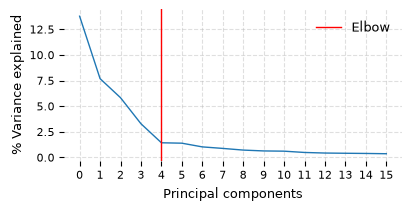

In [1]:
import scarf

scarf.set_verbosity('WARNING')

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)

# HVG columns are stored as `{cell_key}__{hvg_key_name}` (here `I__hvgs`)
if 'I__hvgs' not in ds.RNA.feats.columns:
    ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15, show_elbow_plot=True)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
# Always run layout and clustering on this page so prepared stores still demonstrate the APIs
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)

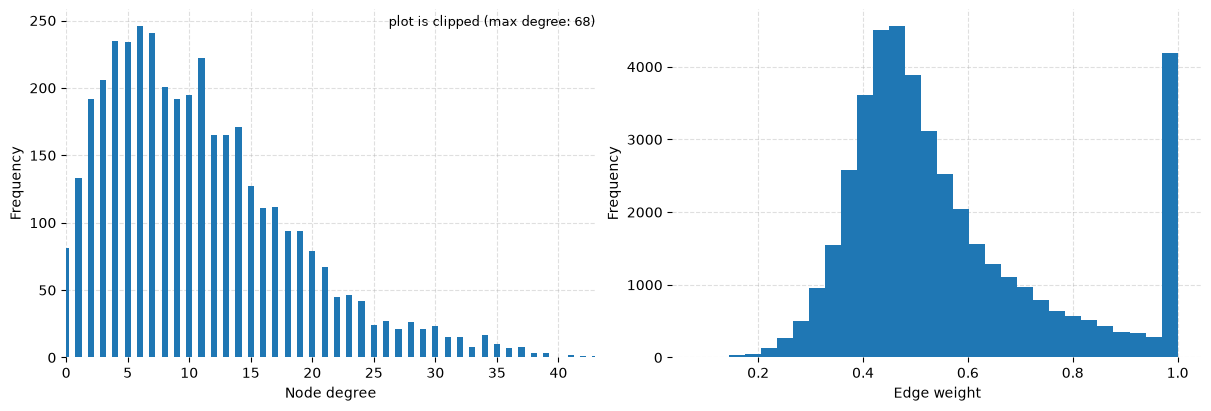

In [2]:
import scarf.plotting as splt

graph = ds.load_graph(
    from_assay='RNA',
    cell_key='I',
    feat_key='hvgs',
    symmetric=False,
    upper_only=False,
)
splt.graph_qc(graph)

In [3]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label='densMAP',
)

In [4]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
)

Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 400: error is 2.8032 (50 iterations in 0.098096 seconds)


Iteration 450: error is 2.76332 (50 iterations in 0.099077 seconds)


Iteration 499: error is 2.75823 (50 iterations in 0.096376 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.157218 sec [22.6631%] |  Repulsive forces: 0.5365 sec [77.3369%]


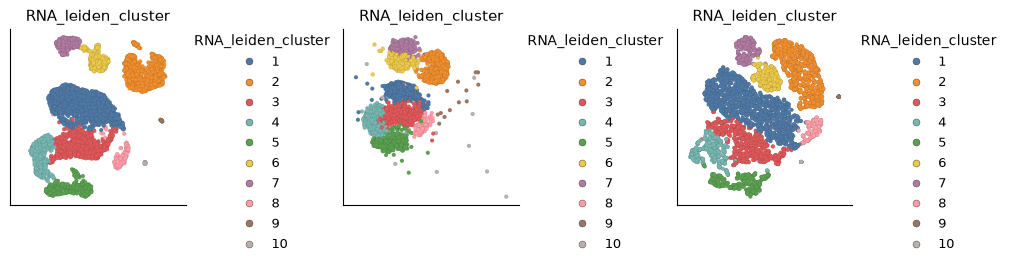

In [5]:
layout_keys = [
    key for key in ['RNA_UMAP', 'RNA_densMAP', 'RNA_tSNE']
    if f'{key}1' in ds.cells.columns
]
ds.plots.embedding(
    layout_key=layout_keys,
    color_by='RNA_leiden_cluster',
    n_columns=len(layout_keys),
)

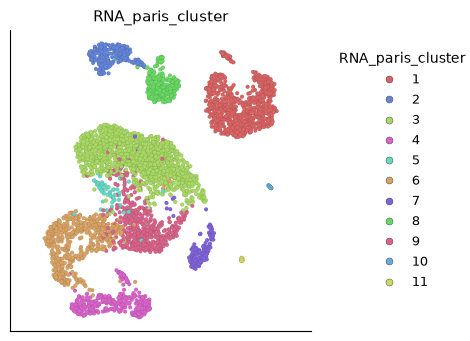

In [6]:
paris = ds.run_paris_clustering()
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris.label_key,
)

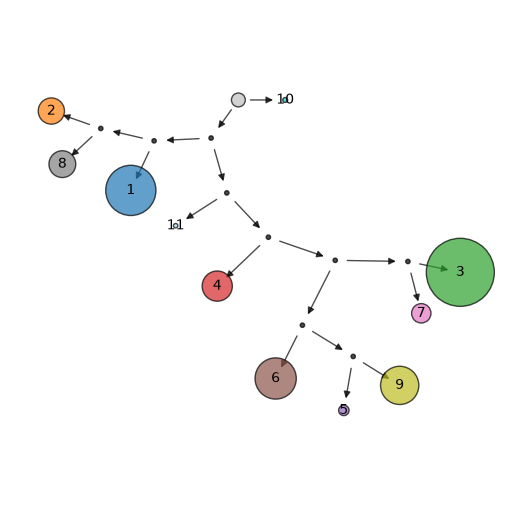

In [7]:
ds.plots.cluster_tree(cluster_key='RNA_paris_cluster', width=1)